=== DATASET DE GENES ===
     gene  expressao  normal  tumor
0   ERBB2      842.5     120    842
1    EGFR      315.2      95    315
2     MYC      421.8     110    421
3    TP53       95.4     130     95
4   BRCA1       88.7     140     88
5  PIK3CA      267.1     100    267
6    PTEN       54.3     125     54
7    KRAS       72.8      90     72
8    AKT1      188.6     115    188
9    CDH1       43.1     150     43

Arquivo CSV salvo com sucesso!

=== CSV CARREGADO ===
     gene  expressao  normal  tumor
0   ERBB2      842.5     120    842
1    EGFR      315.2      95    315
2     MYC      421.8     110    421
3    TP53       95.4     130     95
4   BRCA1       88.7     140     88
5  PIK3CA      267.1     100    267
6    PTEN       54.3     125     54
7    KRAS       72.8      90     72
8    AKT1      188.6     115    188
9    CDH1       43.1     150     43

=== ESTATÍSTICA ===
Média: 238.95
Variância: 61120.96277777777
Desvio Padrão: 247.22654141045976
T-statistic: -1.54311547713663

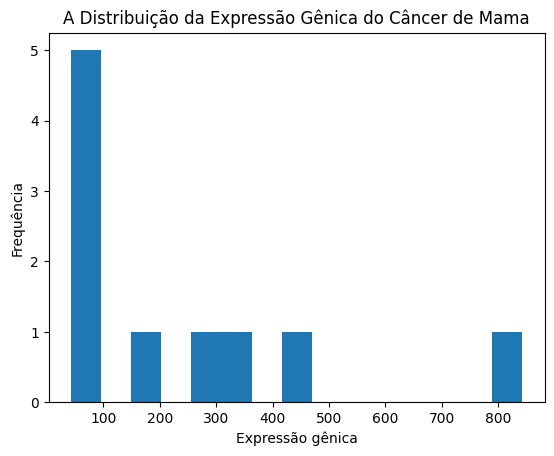


=== INTERPRETAÇÃO ===
Genes com expressão muito alta podem estar associados ao crescimento tumoral e proliferação celular

Genes como EGFR, HER2 e MYC frequentemente aparecem superexpressos em vários tipos de câncer, nesse caso o câncer de mama


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# =========================================================
# 1. CRIANDO DATASET
# =========================================================

genes = pd.DataFrame({
    "gene": ["ERBB2", "EGFR", "MYC", "TP53", "BRCA1", "PIK3CA", "PTEN", "KRAS", "AKT1", "CDH1"],
    "expressao":[842.5, 315.2, 421.8, 95.4, 88.7, 267.1, 54.3, 72.8, 188.6, 43.1],
    "normal": [120, 95, 110, 130, 140, 100, 125, 90, 115, 150],
    "tumor": [842, 315, 421, 95, 88, 267, 54, 72, 188, 43]
})

print("=== DATASET DE GENES ===")
print(genes)

# =========================================================
# 2. SALVANDO CSV
# =========================================================

genes.to_csv("genes_cancer_de_mama.csv", index=False)
print("\nArquivo CSV salvo com sucesso!")

# =========================================================
# 3. LENDO CSV
# =========================================================

genes_cancer_de_mama = pd.read_csv("genes_cancer_de_mama.csv")
print("\n=== CSV CARREGADO ===")
print(genes_cancer_de_mama)

# =========================================================
# 4. ESTATÍSTICAS
# =========================================================

media = genes_cancer_de_mama["expressao"].mean()
variancia = genes_cancer_de_mama["expressao"].var()
dp_cancer_de_mama = genes_cancer_de_mama["expressao"].std()

# Filtrando a coluna de expressão para o grupo normal e grupo tumor
dados_normal = genes["normal"]
dados_tumor = genes["tumor"]
t_stat, p_value = ttest_ind(dados_normal, dados_tumor)

print("\n=== ESTATÍSTICA ===")

print("Média:", media)
print("Variância:", variancia)
print("Desvio Padrão:", dp_cancer_de_mama)
print("T-statistic:", t_stat)
print("P-value:", p_value)

# =========================================================
# 5. GENE MAIS, MENOS E SUPER EXPRESSO
# =========================================================

mais_expresso = genes_cancer_de_mama.loc[genes_cancer_de_mama["expressao"].idxmax()]
menos_expresso = genes_cancer_de_mama.loc[genes_cancer_de_mama["expressao"].idxmin()]
super_expresso = genes_cancer_de_mama[genes_cancer_de_mama["expressao"] > 170]

print("\n=== EXPRESSÃO DOS GENES ===")

print("Genes mais expresso:")
print(mais_expresso)
print("\nGenes menos expresso:") 
print(menos_expresso)
print("\nGenes Super Expresso:") 
print(super_expresso)

# =========================================================
# 6. HISTOGRAMA
# =========================================================

plt.hist(genes_cancer_de_mama["expressao"], bins=15)

plt.xlabel("Expressão gênica")
plt.ylabel("Frequência")
plt.title("A Distribuição da Expressão Gênica do Câncer de Mama")

plt.show()

# =========================================================
# 7. INTERPRETAÇÃO BIOLÓGICA
# =========================================================

print("\n=== INTERPRETAÇÃO ===")

print("Genes com expressão muito alta podem estar associados ao crescimento tumoral e proliferação celular")
print("\nGenes como EGFR, HER2 e MYC frequentemente aparecem superexpressos em vários tipos de câncer, nesse caso o câncer de mama")

# =========================================================
# FIM DO PROJETO
# =========================================================